In [1]:
"""
Attention-BBox Alignment Metrics for ResNet-50 Comparison
Supports both GradCAM (baseline) and Spatial Attention (enhanced)
"""

import torch
import torch.nn.functional as F
import numpy as np
import cv2
from sklearn.metrics import auc
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import timm
import cv2

c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Paths
split_base_path = "./dataset_nodule21/cxr_images/proccessed_data/split_data"
checkpoint_path = "./resnet50_binary.pth"

train_images_path = f"{split_base_path}/train/images"
val_images_path = f"{split_base_path}/val/images"
test_images_path = f"{split_base_path}/test/images"

train_csv_path = f"{split_base_path}/train/metadata_no_aug.csv"
val_csv_path = f"{split_base_path}/val/metadata_val.csv"
test_csv_path = f"{split_base_path}/test/metadata_test.csv"

# ============================================================================
# LOAD DATA
# ============================================================================

print("\nLoading datasets...")
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets with bbox
from NoduleDS import NoduleDataset

train_dataset = NoduleDataset(train_df, train_images_path, transform=train_transform, return_bbox=True)
val_dataset = NoduleDataset(val_df, val_images_path, transform=val_transform, return_bbox=True)
test_dataset = NoduleDataset(test_df, test_images_path, transform=val_transform, return_bbox=True)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)



Loading datasets...
Train samples: 3657
Val samples: 782
Test samples: 785


In [3]:
# ============================================================================
# Spatial Attention Module
# ============================================================================

class SpatialAttentionModule(nn.Module):
    """
    Learnable spatial attention module
    Takes features from backbone and outputs spatial attention weights
    """
    def __init__(self, in_channels=2048, reduction=8):
        super(SpatialAttentionModule, self).__init__()
        
        # Spatial attention pathway
        self.conv1 = nn.Conv2d(in_channels, in_channels // reduction, kernel_size=1)
        self.bn1 = nn.BatchNorm2d(in_channels // reduction)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(in_channels // reduction, in_channels // reduction, 
                               kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(in_channels // reduction)
        
        # Output attention map
        self.conv_out = nn.Conv2d(in_channels // reduction, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        """
        Args:
            x: [B, 2048, 7, 7] features from backbone
        Returns:
            attention: [B, 1, 7, 7] spatial attention map
            weighted_features: [B, 2048, 7, 7] attention-weighted features
        """
        # Generate spatial attention
        att = self.conv1(x)
        att = self.bn1(att)
        att = self.relu(att)
        
        att = self.conv2(att)
        att = self.bn2(att)
        att = self.relu(att)
        
        att = self.conv_out(att)
        attention = self.sigmoid(att)  # [B, 1, 7, 7]
        
        # Apply attention to features
        weighted_features = x * attention
        
        return attention, weighted_features

In [4]:
# ============================================================================
# WSOD Model with Spatial Attention
# ============================================================================

class WSODModelWithAttention(nn.Module):
    def __init__(self, base_model, num_classes=2, freeze_backbone=True):
        super(WSODModelWithAttention, self).__init__()
        
        # Freeze backbone if requested
        if freeze_backbone:
            for param in base_model.parameters():
                param.requires_grad = False
            print("✓ Backbone frozen")
        
        # Extract feature extractor (everything except FC)
        self.features = nn.Sequential(*list(base_model.children())[:-2])  # Up to layer4
        self.avgpool = list(base_model.children())[-2]  # AdaptiveAvgPool2d
        
        # Add spatial attention module (TRAINABLE)
        self.spatial_attention = SpatialAttentionModule(in_channels=2048)
        
        # Classifier head (TRAINABLE)
        self.fc = nn.Linear(2048, num_classes)
        
        # If backbone is frozen, unfreeze only the FC from base_model
        if freeze_backbone:
            # Copy weights from original FC if available
            original_fc = list(base_model.children())[-1]
            if isinstance(original_fc, nn.Linear):
                self.fc.weight.data.copy_(original_fc.weight.data)
                self.fc.bias.data.copy_(original_fc.bias.data)
        
    def forward(self, x, return_attention=False):
        # Extract features from frozen backbone
        features = self.features(x)  # [B, 2048, 7, 7]
        
        # Apply spatial attention
        attention_map, weighted_features = self.spatial_attention(features)
        
        # Global average pooling
        pooled = self.avgpool(weighted_features)  # [B, 2048, 1, 1]
        pooled = pooled.flatten(1)  # [B, 2048]
        
        # Classification
        output = self.fc(pooled)
        
        if return_attention:
            return output, attention_map
        return output
    
    def get_attention_map(self, x):
        """Get spatial attention map for visualization"""
        with torch.no_grad():
            features = self.features(x)
            attention_map, _ = self.spatial_attention(features)
        return attention_map

In [5]:
# ============================================================================
# GRADCAM IMPLEMENTATION (for baseline model)
# ============================================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_image, class_idx=None):
        """Generate GradCAM heatmap"""
        # Forward pass
        model_output = self.model(input_image)
        
        if class_idx is None:
            class_idx = model_output.argmax(dim=1).item()
        
        # Backward pass
        self.model.zero_grad()
        class_score = model_output[0, class_idx]
        class_score.backward()
        
        # Generate CAM
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        for i in range(self.activations.shape[1]):
            self.activations[:, i, :, :] *= pooled_gradients[i]
        
        heatmap = torch.mean(self.activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= (torch.max(heatmap) + 1e-8)
        
        return heatmap.cpu().numpy()


In [20]:
# ============================================================================
# ATTENTION-BBOX ALIGNMENT METRICS
# ============================================================================

class AttentionBBoxMetrics:
    """
    Comprehensive metrics for evaluating attention-bbox alignment
    Works with both GradCAM and Spatial Attention models
    """
    
    def __init__(self, model, device, use_gradcam=False, target_size=224):
        self.model = model
        self.device = device
        self.use_gradcam = use_gradcam
        self.target_size = target_size
        
        # Initialize GradCAM if needed
        if use_gradcam:
            # For timm ResNet models, access layer4 directly
            target_layer = model.layer4[-1]
            self.gradcam = GradCAM(model, target_layer)
            print(f"  Using GradCAM for attention visualization")
        else:
            self.gradcam = None
            print(f"  Using Spatial Attention for visualization")
    
    def compute_bbox_mask(self, bbox, size=224):
        """
        Create binary mask from normalized bbox coordinates
        
        Args:
            bbox: [x, y, w, h] normalized to [0, 1]
            size: output mask size (default 224)
        
        Returns:
            Binary mask of shape (size, size)
        """
        mask = np.zeros((size, size), dtype=np.float32)
        
        x, y, w, h = bbox.cpu().numpy()
        x_pix = int(x * size)
        y_pix = int(y * size)
        w_pix = int(w * size)
        h_pix = int(h * size)
        
        # Clamp to valid range
        x_end = min(x_pix + w_pix, size)
        y_end = min(y_pix + h_pix, size)
        x_pix = max(0, x_pix)
        y_pix = max(0, y_pix)
        
        mask[y_pix:y_end, x_pix:x_end] = 1.0
        return mask
    
    def get_attention_map(self, image):
        """
        Extract and resize attention map from model
        
        Args:
            image: Input tensor [C, H, W]
        
        Returns:
            Attention map resized to target_size × target_size
        """
        self.model.eval()
        
        if self.use_gradcam:
            # Use GradCAM for baseline model (requires gradients)
            image_batch = image.unsqueeze(0).to(self.device)
            image_batch.requires_grad = True
            attention_map = self.gradcam.generate_cam(image_batch)
            
        else:
            # Use spatial attention for enhanced model (no gradients needed)
            with torch.no_grad():
                if hasattr(self.model, 'get_attention_map'):
                    attention_map = self.model.get_attention_map(
                        image.unsqueeze(0).to(self.device)
                    )
                    attention_map = attention_map.squeeze().cpu().numpy()
                else:
                    raise ValueError("Model doesn't have get_attention_map method")
        
        # Resize to target size
        if attention_map.shape != (self.target_size, self.target_size):
            attention_map = cv2.resize(attention_map, (self.target_size, self.target_size))
        
        return attention_map
    
    def compute_iou_score(self, attention_map, bbox):
        """
        Compute IoU between thresholded attention and bbox
        
        Args:
            attention_map: Attention heatmap (H, W)
            bbox: Ground truth bbox [x, y, w, h]
        
        Returns:
            IoU score
        """
        # Threshold attention at median
        threshold = np.median(attention_map)
        attention_binary = (attention_map > threshold).astype(np.float32)
        
        # Get bbox mask
        bbox_mask = self.compute_bbox_mask(bbox, self.target_size)
        
        # Compute IoU
        intersection = np.sum(attention_binary * bbox_mask)
        union = np.sum((attention_binary + bbox_mask) > 0)
        
        if union == 0:
            return 0.0
        
        return intersection / union
    
    def compute_coverage_score(self, attention_map, bbox):
        """
        Compute what percentage of bbox area is covered by high attention
        
        Args:
            attention_map: Attention heatmap (H, W)
            bbox: Ground truth bbox [x, y, w, h]
        
        Returns:
            Coverage score (0-1)
        """
        bbox_mask = self.compute_bbox_mask(bbox, self.target_size)
        
        # Extract attention values within bbox
        attention_in_bbox = attention_map * bbox_mask
        
        if np.sum(bbox_mask) == 0:
            return 0.0
        
        # Mean attention within bbox region
        coverage = np.sum(attention_in_bbox) / np.sum(bbox_mask)
        
        return coverage
    
    def compute_peak_alignment_score(self, attention_map, bbox):
        """
        Check if attention peak is within bbox
        Gives bonus for peaks closer to bbox center
        
        Args:
            attention_map: Attention heatmap (H, W)
            bbox: Ground truth bbox [x, y, w, h]
        
        Returns:
            Score (0-1), higher if peak is centered in bbox
        """
        # Find peak location
        peak_idx = np.unravel_index(np.argmax(attention_map), attention_map.shape)
        peak_y, peak_x = peak_idx
        
        # Get bbox info
        x, y, w, h = bbox.cpu().numpy()
        bbox_x = x * self.target_size
        bbox_y = y * self.target_size
        bbox_w = w * self.target_size
        bbox_h = h * self.target_size
        
        bbox_center_x = bbox_x + bbox_w / 2
        bbox_center_y = bbox_y + bbox_h / 2
        
        # Check if peak is inside bbox
        if (bbox_x <= peak_x <= bbox_x + bbox_w and 
            bbox_y <= peak_y <= bbox_y + bbox_h):
            
            # Compute distance from peak to bbox center
            dist_x = abs(peak_x - bbox_center_x)
            dist_y = abs(peak_y - bbox_center_y)
            
            # Normalize by bbox dimensions
            norm_dist_x = dist_x / (bbox_w / 2) if bbox_w > 0 else 0
            norm_dist_y = dist_y / (bbox_h / 2) if bbox_h > 0 else 0
            
            # Score: 1.0 at center, decreases with distance
            score = 1.0 - (norm_dist_x + norm_dist_y) / 2
            return max(0, score)
        else:
            return 0.0
    
    def compute_precision_at_k(self, attention_map, bbox, k_percent=0.2):
        """
        Precision@K: What % of top-k% attention pixels fall within bbox?
        
        Args:
            attention_map: Attention heatmap (H, W)
            bbox: Ground truth bbox [x, y, w, h]
            k_percent: Top K% of pixels to consider (default 20%)
        
        Returns:
            Precision score (0-1)
        """
        bbox_mask = self.compute_bbox_mask(bbox, self.target_size)
        
        # Flatten and sort attention values
        flat_attention = attention_map.flatten()
        k = int(len(flat_attention) * k_percent)
        
        # Get top-k indices
        top_k_indices = np.argpartition(flat_attention, -k)[-k:]
        
        # Create mask for top-k pixels
        top_k_mask = np.zeros_like(flat_attention)
        top_k_mask[top_k_indices] = 1
        top_k_mask = top_k_mask.reshape(attention_map.shape)
        
        # Count how many top-k pixels are in bbox
        precision = np.sum(top_k_mask * bbox_mask) / k if k > 0 else 0
        
        return precision
    
    def compute_all_metrics(self, image, bboxes, label):
        """
        Compute all metrics for a single image with multiple bboxes
        
        Args:
            image: Input image tensor
            bboxes: List of bbox tensors or single bbox
            label: Ground truth label (0 or 1)
        
        Returns:
            Dictionary of metrics
        """
        # Get attention map
        attention_map = self.get_attention_map(image)
        
        if label == 0:
            # No nodule - return zero scores
            return {
                'iou': 0.0,
                'coverage': 0.0,
                'peak_alignment': 0.0,
                'precision_at_20': 0.0,
                'has_nodule': False,
                'num_nodules': 0
            }
        
        # Handle single bbox or list
        if not isinstance(bboxes, list):
            bboxes = [bboxes]
        
        # Compute metrics for each bbox and aggregate
        iou_scores = []
        coverage_scores = []
        peak_scores = []
        precision_scores = []
        
        for bbox in bboxes:
            iou_scores.append(self.compute_iou_score(attention_map, bbox))
            coverage_scores.append(self.compute_coverage_score(attention_map, bbox))
            peak_scores.append(self.compute_peak_alignment_score(attention_map, bbox))
            precision_scores.append(self.compute_precision_at_k(attention_map, bbox))
        
        # Aggregate: use max for peak alignment, mean for others
        return {
            'iou': np.mean(iou_scores),
            'coverage': np.mean(coverage_scores),
            'peak_alignment': np.max(peak_scores),  # Best peak alignment
            'precision_at_20': np.mean(precision_scores),
            'has_nodule': True,
            'num_nodules': len(bboxes)
        }
    
    def evaluate_dataset(self, dataset, max_samples=None):
        """
        Evaluate model on entire dataset
        
        Args:
            dataset: Dataset with return_bbox=True
            max_samples: Limit number of samples (None for all)
        
        Returns:
            Dictionary with aggregated metrics
        """
        all_metrics = []
        
        num_samples = len(dataset) if max_samples is None else min(max_samples, len(dataset))
        
        for i in tqdm(range(num_samples), desc="Evaluating attention alignment"):
            image, label, bbox = dataset[i]
            
            # Get all bboxes for this image if multiple nodules exist
            img_name = dataset.df.iloc[i]['img_name']
            patient_rows = dataset.df[dataset.df['img_name'] == img_name]
            
            all_bboxes = []
            
            # Get original dimensions
            if 'img_width' in patient_rows.columns and 'img_height' in patient_rows.columns:
                img_width = patient_rows.iloc[0]['img_width']
                img_height = patient_rows.iloc[0]['img_height']
            else:
                img_width = 1024
                img_height = 1024
            
            for _, row in patient_rows.iterrows():
                if row['label'] == 1:
                    # Normalize bbox coordinates
                    bbox_tensor = torch.tensor([
                        row['x'] / img_width,
                        row['y'] / img_height,
                        row['width'] / img_width,
                        row['height'] / img_height
                    ], dtype=torch.float32)
                    all_bboxes.append(bbox_tensor)
            
            # Use all bboxes or empty list for negatives
            bboxes_to_use = all_bboxes if len(all_bboxes) > 0 else []
            
            metrics = self.compute_all_metrics(image, bboxes_to_use, label.item())
            all_metrics.append(metrics)
        
        # Aggregate results
        return self._aggregate_metrics(all_metrics)
    
    def _aggregate_metrics(self, all_metrics):
        """Aggregate metrics across dataset"""
        # Separate positive and negative samples
        positive_metrics = [m for m in all_metrics if m['has_nodule']]
        negative_metrics = [m for m in all_metrics if not m['has_nodule']]
        
        results = {
            'overall': {},
            'positive_samples': {},
            'negative_samples': {},
            'num_positive': len(positive_metrics),
            'num_negative': len(negative_metrics),
            'total_nodules': sum(m['num_nodules'] for m in positive_metrics)
        }
        
        # Compute means for positive samples
        if positive_metrics:
            results['positive_samples'] = {
                'iou': np.mean([m['iou'] for m in positive_metrics]),
                'coverage': np.mean([m['coverage'] for m in positive_metrics]),
                'peak_alignment': np.mean([m['peak_alignment'] for m in positive_metrics]),
                'precision_at_20': np.mean([m['precision_at_20'] for m in positive_metrics]),
            }
        
        # Overall metrics (positive only, since negatives are always 0)
        if positive_metrics:
            results['overall'] = results['positive_samples'].copy()
        
        return results

In [7]:
# ============================================================================
# MODEL COMPARISON FUNCTION
# ============================================================================

def compare_models(baseline_model, enhanced_model, test_dataset, device, 
                   model_names=['Baseline ResNet-50 (GradCAM)', 'Enhanced ResNet-50 (Spatial Attention)']):
    """
    Compare baseline (GradCAM) and enhanced (Spatial Attention) models
    
    Args:
        baseline_model: Original ResNet-50 (uses GradCAM)
        enhanced_model: ResNet-50 with spatial attention
        test_dataset: Test dataset with return_bbox=True
        device: torch device
        model_names: Names for models
    
    Returns:
        Comparison results dictionary
    """
    print("=" * 80)
    print("ATTENTION-BBOX ALIGNMENT COMPARISON")
    print("=" * 80)
    
    # Evaluate baseline with GradCAM
    print(f"\nEvaluating {model_names[0]}...")
    baseline_evaluator = AttentionBBoxMetrics(baseline_model, device, use_gradcam=True)
    baseline_results = baseline_evaluator.evaluate_dataset(test_dataset)
    
    # Evaluate enhanced with Spatial Attention
    print(f"\nEvaluating {model_names[1]}...")
    enhanced_evaluator = AttentionBBoxMetrics(enhanced_model, device, use_gradcam=False)
    enhanced_results = enhanced_evaluator.evaluate_dataset(test_dataset)
    
    # Print comparison
    print("\n" + "=" * 80)
    print("RESULTS COMPARISON")
    print("=" * 80)
    
    print(f"\nDataset Statistics:")
    print(f"  Positive samples: {enhanced_results['num_positive']}")
    print(f"  Negative samples: {enhanced_results['num_negative']}")
    print(f"  Total nodules: {enhanced_results['total_nodules']}")
    
    metrics_names = {
        'iou': 'IoU Score',
        'coverage': 'Coverage Score',
        'peak_alignment': 'Peak Alignment',
        'precision_at_20': 'Precision@20%'
    }
    
    print(f"\n{'Metric':<20} {'Baseline':<15} {'Enhanced':<15} {'Improvement':<15}")
    print("-" * 65)
    
    for key, name in metrics_names.items():
        baseline_val = baseline_results['positive_samples'].get(key, 0)
        enhanced_val = enhanced_results['positive_samples'].get(key, 0)
        improvement = enhanced_val - baseline_val
        improvement_pct = (improvement / baseline_val * 100) if baseline_val > 0 else 0
        
        print(f"{name:<20} {baseline_val:>7.4f}       {enhanced_val:>7.4f}       "
              f"{improvement:>+7.4f} ({improvement_pct:>+6.2f}%)")
    
    # Visualization
    plot_comparison(baseline_results, enhanced_results, model_names)
    
    return {
        'baseline': baseline_results,
        'enhanced': enhanced_results,
        'model_names': model_names
    }


def plot_comparison(baseline_results, enhanced_results, model_names):
    """Create comparison visualization"""
    metrics = ['iou', 'coverage', 'peak_alignment', 'precision_at_20']
    metric_labels = ['IoU', 'Coverage', 'Peak\nAlignment', 'Precision@20']
    
    baseline_vals = [baseline_results['positive_samples'].get(m, 0) for m in metrics]
    enhanced_vals = [enhanced_results['positive_samples'].get(m, 0) for m in metrics]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    rects1 = ax.bar(x - width/2, baseline_vals, width, label=model_names[0], alpha=0.8, color='#ff7f0e')
    rects2 = ax.bar(x + width/2, enhanced_vals, width, label=model_names[1], alpha=0.8, color='#2ca02c')
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Attention-BBox Alignment Metrics Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    ax.legend()
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                       xy=(rect.get_x() + rect.get_width() / 2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=9)
    
    autolabel(rects1)
    autolabel(rects2)
    
    plt.tight_layout()
    plt.show()

In [18]:
# ============================================================================
# HELPER FUNCTION TO LOAD MODELS
# ============================================================================

def load_baseline_model(checkpoint_path, device):
    """
    Load baseline ResNet-50 model from checkpoint
    Handles different checkpoint formats
    """
    import timm
    
    # Create model with same architecture
    model = timm.create_model('resnet50', pretrained=False, num_classes=2)
    
    # Load checkpoint
    print(f"Loading baseline model from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Handle different checkpoint formats
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
        print(f"  Found 'model_state_dict' key")
        if 'epoch' in checkpoint:
            print(f"  Checkpoint from epoch: {checkpoint['epoch']}")
        if 'val_acc' in checkpoint:
            print(f"  Validation accuracy: {checkpoint['val_acc']:.2f}%")
    elif 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
        print(f"  Found 'state_dict' key")
    else:
        state_dict = checkpoint
        print(f"  Using checkpoint directly as state_dict")
    
    # Check if keys have 'module.' prefix (from DataParallel)
    first_key = list(state_dict.keys())[0]
    if first_key.startswith('module.'):
        print(f"  Removing 'module.' prefix from keys")
        state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
    
    # Try to load
    try:
        model.load_state_dict(state_dict, strict=True)
        print("✓ Loaded baseline model successfully (strict=True)")
    except Exception as e:
        print(f"⚠ Warning: Could not load with strict=True")
        print(f"  Error: {str(e)[:100]}...")
        model.load_state_dict(state_dict, strict=False)
        print("✓ Loaded baseline model with strict=False")
    
    model = model.to(device)
    model.eval()
    
    return model

def load_enhanced_model(checkpoint_path, base_model, device, freeze_backbone=True):
    """
    Load enhanced model with spatial attention from checkpoint
    Handles different checkpoint formats
    """
    # Create enhanced model wrapper
    enhanced_model = WSODModelWithAttention(base_model, num_classes=2, freeze_backbone=freeze_backbone)
    enhanced_model = enhanced_model.to(device)
    
    # Load checkpoint
    print(f"Loading enhanced model from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Handle different checkpoint formats
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
        print(f"  Found 'model_state_dict' key")
        if 'epoch' in checkpoint:
            print(f"  Checkpoint from epoch: {checkpoint['epoch']}")
        if 'val_acc' in checkpoint:
            print(f"  Validation accuracy: {checkpoint['val_acc']:.2f}%")
        if 'val_att_iou' in checkpoint:
            print(f"  Attention IoU: {checkpoint['val_att_iou']:.4f}")
    elif 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
        print(f"  Found 'state_dict' key")
    else:
        state_dict = checkpoint
        print(f"  Using checkpoint directly as state_dict")
    
    # Load state dict
    enhanced_model.load_state_dict(state_dict)
    enhanced_model.eval()
    print("✓ Loaded enhanced model successfully")
    
    return enhanced_model


Loading baseline model from: ./best_resnet_nodule_model(NEW).pth
  Found 'model_state_dict' key
  Checkpoint from epoch: 24
  Validation accuracy: 96.68%
✓ Loaded baseline model successfully (strict=True)
✓ Backbone frozen
Loading enhanced model from: best_wsod_attention_resnet50.pth
  Found 'model_state_dict' key
  Checkpoint from epoch: 4
  Validation accuracy: 95.65%
  Attention IoU: 0.0189
✓ Loaded enhanced model successfully
ATTENTION-BBOX ALIGNMENT COMPARISON

Evaluating Baseline ResNet-50 (GradCAM)...
  Using GradCAM for attention visualization


Evaluating attention alignment: 100%|██████████| 785/785 [02:02<00:00,  6.39it/s]



Evaluating ResNet-50 + Spatial Attention...
  Using Spatial Attention for visualization


Evaluating attention alignment: 100%|██████████| 785/785 [00:34<00:00, 22.73it/s]



RESULTS COMPARISON

Dataset Statistics:
  Positive samples: 217
  Negative samples: 568
  Total nodules: 359

Metric               Baseline        Enhanced        Improvement    
-----------------------------------------------------------------
IoU Score             0.0059        0.0067       +0.0008 (+12.87%)
Coverage Score        0.2871        0.3993       +0.1122 (+39.09%)
Peak Alignment        0.0034        0.0268       +0.0234 (+678.74%)
Precision@20%         0.0083        0.0132       +0.0049 (+59.12%)


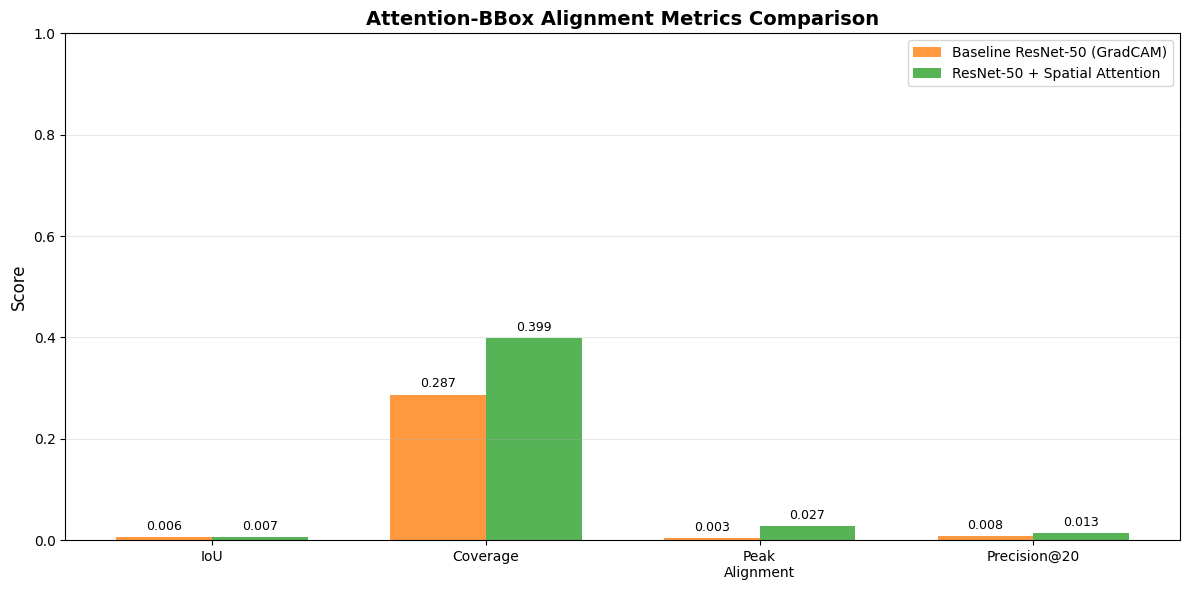


Comparison complete!


In [21]:
# ============================================================================
# EXAMPLE USAGE
# ============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

baseline_model = load_baseline_model('./best_resnet_nodule_model(NEW).pth', device)

# Load enhanced model
base_model = timm.create_model('resnet50', pretrained=False, num_classes=2)
enhanced_model = load_enhanced_model(
    checkpoint_path='best_wsod_attention_resnet50.pth',
    base_model=base_model,
    device=device,
    freeze_backbone=True
)
# Make sure your test_dataset has return_bbox=True
# Run comparison
comparison_results = compare_models(
    baseline_model=baseline_model,
    enhanced_model=enhanced_model,
    test_dataset=test_dataset,
    device=device,
    model_names=['Baseline ResNet-50 (GradCAM)', 'ResNet-50 + Spatial Attention']
)

# Results are stored in comparison_results dictionary
print("\nComparison complete!")